Importing Libraries

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
import torch
from datasets import Dataset
#from sentence_transformers import SentenceTransformer
from scipy.spatial.distance import cosine
import seaborn as sns
from itertools import combinations
from collections import Counter

**Loading the Dataset**

In [42]:
session_data=pd.read_csv('session_data.csv')
session_data.head(10)

,session_id,product_name
0,000ed966131fcb96e0efc4ff2b716a3e,beetroot
1,000ed966131fcb96e0efc4ff2b716a3e,cucumber
2,0013eab657eaf2d82d7f1e13023d95c2,onion
3,0013eab657eaf2d82d7f1e13023d95c2,long shelf life milk
4,0013fabde1e543dd541be925266aadbc,dates
5,0013fabde1e543dd541be925266aadbc,matchbox
6,001dcafde327359bfb3d62903280e23c,onion
7,001dcafde327359bfb3d62903280e23c,brinjal
8,00380e30a223b94428c3bb48142f8821,cucumber
9,00380e30a223b94428c3bb48142f8821,gourds


In [43]:
# check the dataTypes and missing values
session_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 345152 entries, 0 to 345151
Data columns (total 2 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   session_id    345152 non-null  object
 1   product_name  345152 non-null  object
dtypes: object(2)
memory usage: 5.3+ MB


In [44]:
#check the missing values
session_data.isnull().sum()


,0
session_id,0
product_name,0


In [45]:
# now we check number of unique users and items in the dataset
num_sessions= session_data['session_id'].nunique()
num_products = session_data['product_name'].nunique()
print(f'Number of unique sessions: {num_sessions}')
print(f'Number of unique products: {num_products}')

Number of unique sessions: 165335
Number of unique products: 396


In [46]:
# Distribution of products per session that means how many products are there in each session
products_per_session = session_data.groupby('session_id').size()
print(products_per_session.describe())

count    165335.000000
mean          2.087592
std           0.323845
min           2.000000
25%           2.000000
50%           2.000000
75%           2.000000
max           9.000000
dtype: float64


so the average number of products per session is 2.5 and the maximum number of products in a session is 9 and the minimum is 2.

In [47]:
# Distribution of sessions per product means how many sessions are there for each product
sessions_per_product = session_data.groupby('product_name').size()
print(sessions_per_product.describe())


count      396.000000
mean       871.595960
std       2730.275337
min          1.000000
25%         44.000000
50%        151.500000
75%        540.250000
max      31196.000000
dtype: float64


In [48]:
# Most and least frequent products
most_frequent_products = sessions_per_product.sort_values(ascending=False).head(10)
least_frequent_products = sessions_per_product.sort_values(ascending=True).head(10)
print("Most Frequent Products:")
print(most_frequent_products)
print("\nLeast Frequent Products:")
print(least_frequent_products)

Most Frequent Products:
product_name
onion                   31196
cucumber                19083
fresh cow milk          18086
beetroot                17077
gourds                  15625
curd                    15578
long shelf life milk    10336
garlic                   9222
tender coconut           9155
detergent powder         8414
dtype: int64

Least Frequent Products:
product_name
suitcase            1
cola drinks         1
coriander leaves    1
plant based         1
oxymeter            1
food wrapping       1
holi needs          1
ice apple           1
shringar            1
moth dal            1
dtype: int64


In [49]:
# average number of products per session
average_products_per_session = products_per_session.mean()
print(f'Average number of products per session: {average_products_per_session:.2f}')

# session with the most and least number of products
most_products_session = products_per_session.idxmax()
least_products_session = products_per_session.idxmin()
print(f"Session with most products: {most_products_session}")
print(f"Session with least products: {least_products_session}")

Average number of products per session: 2.09
Session with most products: 27d86d946e6ea6d022f12211d61f8ac7
Session with least products: 0000bc46bf70d6ebb01c8b58f5e619ab


In [50]:
# Most popular products
popular_products = session_data['product_name'].value_counts().head(10)
print("Most popular products:")
print(popular_products)

Most popular products:
product_name
onion                   31196
cucumber                19083
fresh cow milk          18086
beetroot                17077
gourds                  15625
curd                    15578
long shelf life milk    10336
garlic                   9222
tender coconut           9155
detergent powder         8414
Name: count, dtype: int64


In [51]:
# Create a list of product lists for each session
product_lists = session_data.groupby('session_id')['product_name'].apply(list)

# Count co-occurrences
co_occurrences = Counter()
for product_list in product_lists:
    for combo in combinations(product_list, 2):
        co_occurrences[tuple(sorted(combo))] += 1

# Most common co-occurrences
most_common_co_occurrences = co_occurrences.most_common(10)
print("Most common product co-occurrences:")
print(most_common_co_occurrences)

# this code will be used to find the most similar products based on co-occurrence in sessions. We will use cosine similarity to measure the similarity between products based on their co-occurrence patterns.
# how this code is co_occurrence the product that is buying together ? because if two products are frequently bought together in the same sessions, they will have a high co-occurrence count.
# By calculating the cosine similarity between the co-occurrence vectors of different products, we can identify which products are most similar in terms of their co-occurrence patterns, indicating that they are often bought together.

Most common product co-occurrences:
[(('beetroot', 'cucumber'), 8595), (('long shelf life milk', 'onion'), 5067), (('curd', 'fresh cow milk'), 4408), (('onion', 'tender coconut'), 3618), (('beetroot', 'gourds'), 3419), (('cucumber', 'gourds'), 3198), (('baby fruits', 'onion'), 2540), (('fresh cow milk', 'onion'), 2363), (('fresh beans', 'gourds'), 2027), (('beetroot', 'fresh beans'), 1926)]


**this will give us an idea about which products are often bought together, which can be useful for building a recommendation system based on co-purchasing patterns.**

 what is cosine_similarity? what its use ? how its works

 Cosine similarity is a measure of similarity between two non-zero vectors in an inner product space. It is defined as the cosine of the angle between them, which ranges from -1 to 1. A cosine similarity of 1 indicates that the vectors are identical, while a cosine similarity of 0 indicates that they are orthogonal (i.e., they have no similarity). A cosine similarity of -1 indicates that the vectors are diametrically opposed.

Cosine similarity is commonly used in various applications, including:

eg  1. Text Analysis: It is used to measure the similarity between documents or sentences in  natural language processing tasks.

eg 2. Recommender Systems: It helps in finding similar items or users based on their interactions or preferences.

In [52]:
# show visualization of the most popular products using plotly from high to low popularity use diffrent color for each bar and add title and axis labels

import plotly.express as px
fig = px.bar(popular_products, x=popular_products.index, y=popular_products.values, color=popular_products.index,
title='Most Popular Products', labels={'x': 'Product Name', 'y': 'Number of Sessions'})

fig.show()



In [53]:
"""import seaborn as sns
# Distribution of products per session
products_per_session = session_data.groupby('session_id').size()

plt.figure(figsize=(10, 6))
sns.histplot(products_per_session, bins=30, kde=True)
plt.title('Distribution of Products per Session')
plt.xlabel('Number of Products')
plt.ylabel('Frequency')
plt.show()"""

# plot the same distribution using plotly use different color for the bars and add title and axis labels
import plotly.express as px
fig = px.histogram(products_per_session, x=products_per_session, nbins=30, title='Distribution of Products per Session',
labels={'x': 'Number of Products', 'y': 'Frequency'}, color_discrete_sequence=px.colors.qualitative.D3)
fig.show()



 it means the for 2 products are the peak in the distribution of products per session, indicating that most sessions contain exactly 2 products. This suggests that customers often purchase pairs of products together, which could be useful for recommendation systems to suggest complementary items.

this histogram shows the most of the session have 1 to 5 products and very few session have more than 10 products , that means most of the customers are buying 1 to 5 products in a single session and very few customers are buying more than 10 products in a single session. This information can be useful for understanding customer behavior and for making recommendations based on the number of products in a session.  

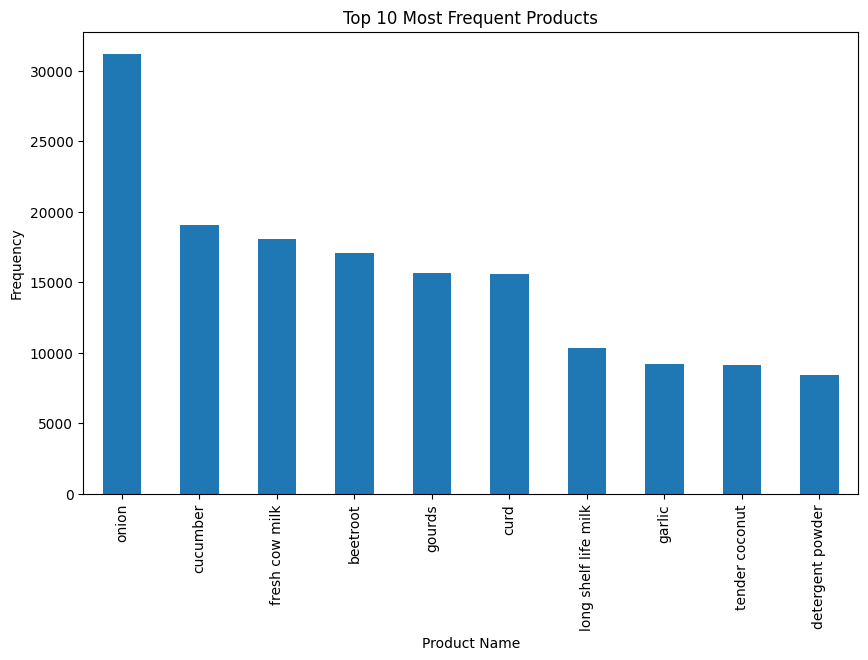

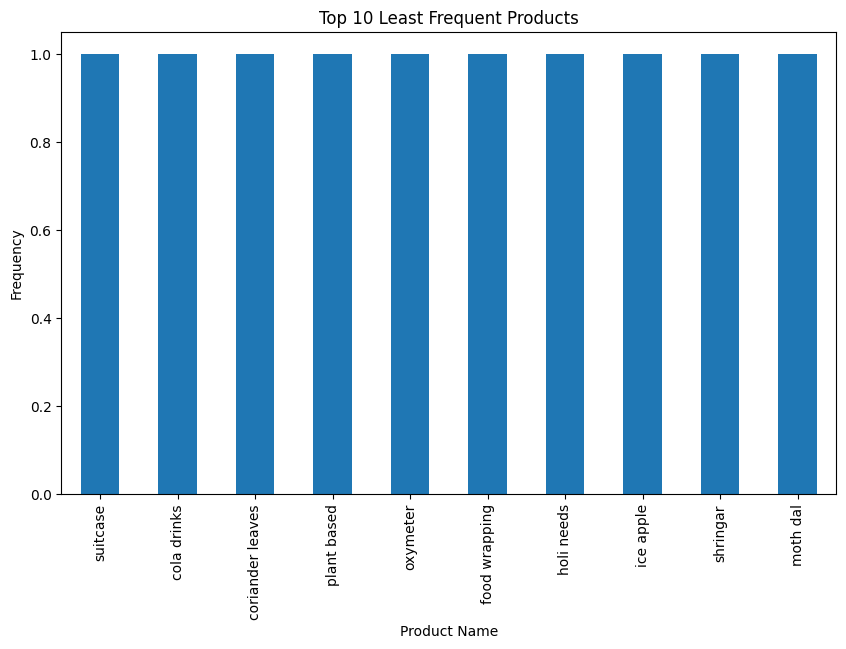

In [54]:
# Distribution of sessions per product
sessions_per_product = session_data.groupby('product_name').size()

# Most frequent products
most_frequent_products = sessions_per_product.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
most_frequent_products.plot(kind='bar')
plt.title('Top 10 Most Frequent Products')
plt.xlabel('Product Name')
plt.ylabel('Frequency')
plt.show()

# Least frequent products
least_frequent_products = sessions_per_product.sort_values(ascending=True).head(10)

plt.figure(figsize=(10, 6))
least_frequent_products.plot(kind='bar')
plt.title('Top 10 Least Frequent Products')
plt.xlabel('Product Name')
plt.ylabel('Frequency')
plt.show()


/tmp/ipykernel_837/3604178074.py:14: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



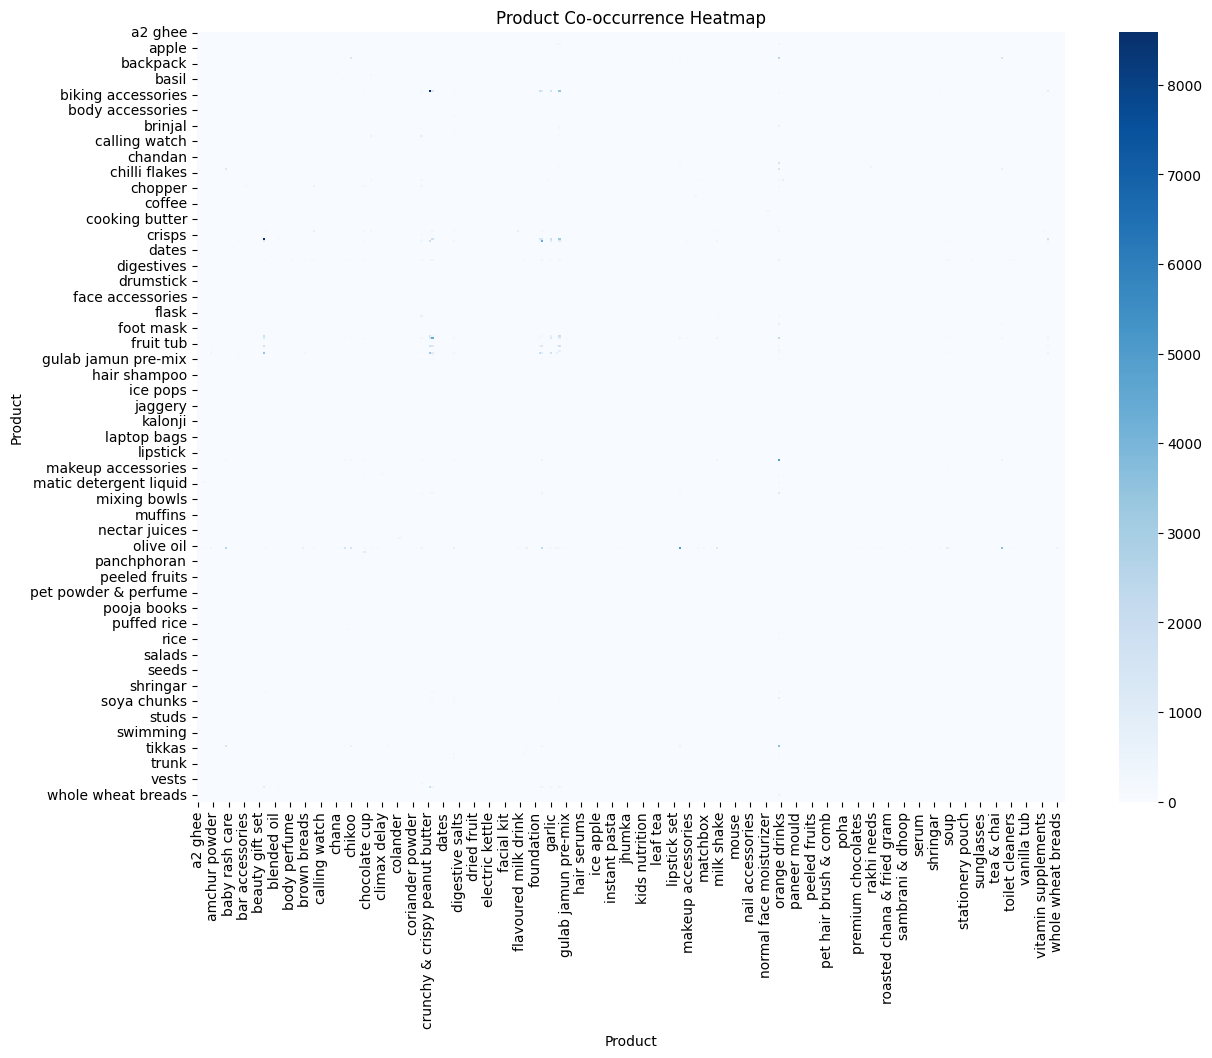

In [55]:
# Create a list of product lists for each session
product_lists = session_data.groupby('session_id')['product_name'].apply(list)

# Count co-occurrences
co_occurrences = Counter()
for product_list in product_lists:
    for combo in combinations(product_list, 2):
        co_occurrences[tuple(sorted(combo))] += 1

# Convert co-occurrences to a DataFrame
co_occurrence_matrix = pd.DataFrame(
    index=sessions_per_product.index,
    columns=sessions_per_product.index
).fillna(0)

for (product1, product2), count in co_occurrences.items():
    co_occurrence_matrix.loc[product1, product2] = count
    co_occurrence_matrix.loc[product2, product1] = count

plt.figure(figsize=(14, 10))
sns.heatmap(co_occurrence_matrix, cmap='Blues')
plt.title('Product Co-occurrence Heatmap')
plt.xlabel('Product')
plt.ylabel('Product')
plt.show()


this heatmap is showing the co-occurrence of products in the sessions. The color intensity in the heatmap represents the frequency of co-occurrence between pairs of products. A darker color indicates a higher frequency of co-occurrence, meaning that those products are often bought together in the same sessions.


In [56]:
# Pie chart for top 10 product distribution using plotly with different colors for each slice and add title and labels
import plotly.express as px
product_distribution = session_data['product_name'].value_counts().head(10)
fig = px.pie(product_distribution, values=product_distribution.values, names=product_distribution.index,
title='Top 10 Product Distribution', color_discrete_sequence=px.colors.qualitative.Set3)
fig.show()




In [57]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np

# Create a string with all product names
text = ' '.join(session_data['product_name'].astype(str))

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

# Convert wordcloud image to a format Plotly can handle
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.savefig('wordcloud.png', format='png')
plt.close()

# Load the image with Plotly
img = px.imshow(np.array(wordcloud))
img.update_layout(
    title='Product Names Word Cloud',
    xaxis_title='',
    yaxis_title='',
    xaxis=dict(showgrid=False, showticklabels=False),
    yaxis=dict(showgrid=False, showticklabels=False)
)

# Show the interactive word cloud
img.show()


In [58]:
from sentence_transformers import SentenceTransformer, models


In [70]:
# compute product embeddings and cosine similarity (uses SentenceTransformer imported in an earlier cell)
# This section of code is no longer needed as 'cosine_sim_df' from SentenceTransformer is not used in the ensemble.

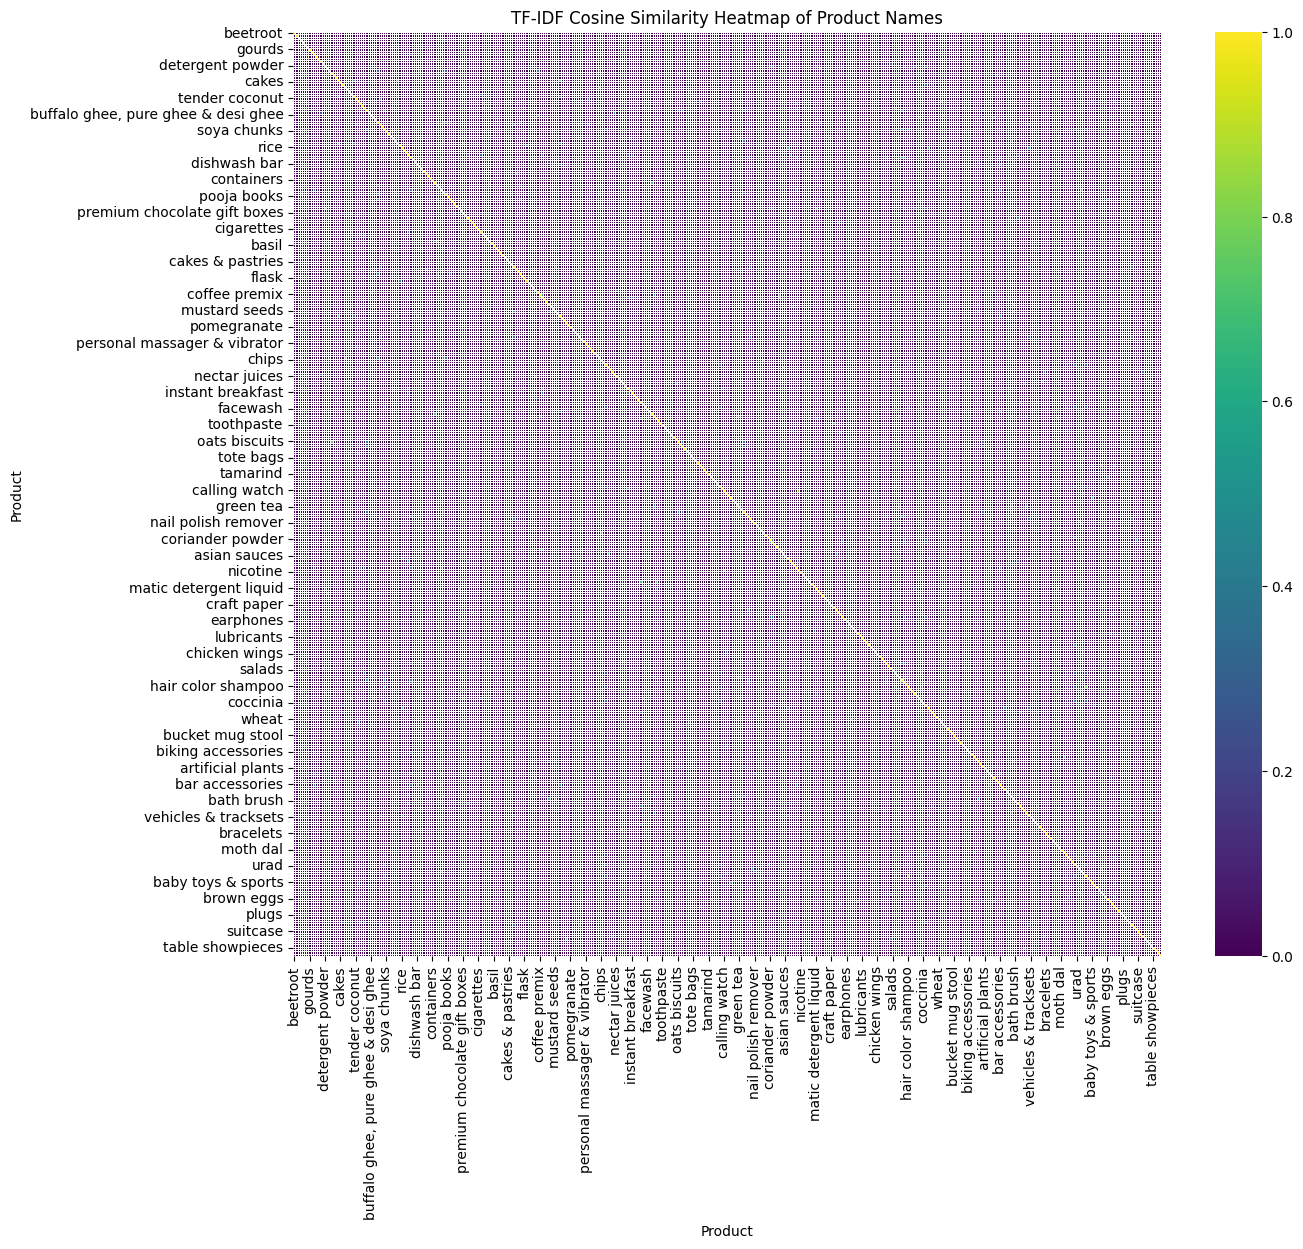

In [71]:
# Create the heatmap for TF-IDF similarity, as it's used in the ensemble
plt.figure(figsize=(14, 12))
sns.heatmap(tfidf_sim_df, cmap='viridis', annot=False, fmt=".2f", linewidths=0.5)

# Update plot titles and labels
plt.title('TF-IDF Cosine Similarity Heatmap of Product Names')
plt.xlabel('Product')
plt.ylabel('Product')

# Show the plot
plt.show()

In [73]:
# Add Quantity column and pivot the data
session_data["Quantity"] = 1
dataWide = session_data.pivot(index="session_id", columns="product_name", values="Quantity")
dataWide.fillna(0, inplace=True)

# Prepare data for item-based similarity calculations
data_ib = dataWide.copy()
data_ib = data_ib.reset_index()
data_ib = data_ib.drop("session_id", axis=1)

# Initialize similarity dataframe for item-based similarities
data_ibs = pd.DataFrame(index=data_ib.columns, columns=data_ib.columns)

we have added quantity column for 1 because we want to count the number of times a product is bought in a session. This will help us to calculate the co-occurrence of products in sessions and also to calculate the similarity between products based on their co-occurrence patterns. By counting the quantity of each product in a session, we can better understand the relationships between products and make more accurate recommendations based on user behavior.  

In [74]:
# Calculate cosine similarities between products for item-based recommendations
for i in range(len(data_ibs.columns)):
    for j in range(len(data_ibs.columns)):
        if i != j:
            data_ibs.iloc[i, j] = 1 - cosine(data_ib.iloc[:, i], data_ib.iloc[:, j])
        else:
            data_ibs.iloc[i, j] = 0


we have calculated the cosine similarity between products based on their co-occurrence in sessions. This allows us to identify which products are most similar to each other, indicating that they are often bought together. By analyzing the similarity matrix, we can make recommendations for products that are frequently purchased together, enhancing the recommendation system's effectiveness.

In [75]:
# Ensure product names are in a list of lists format suitable for TF-IDF
product_names = session_data['product_name'].unique().tolist()
sentences = [[product] for product in product_names]



we can use the TfidfVectorizer to compute TF-IDF scores for the product names and then calculate cosine similarity based on these scores. This will help us understand the similarity between products based on their TF-IDF representations.

In [76]:
# Assume session_data['product_name'] contains the product names
product_names = session_data['product_name'].unique().tolist()

# Create a TF-IDF Vectorizer
vectorizer = TfidfVectorizer()

# Fit and transform the product names to get TF-IDF matrix
tfidf_matrix = vectorizer.fit_transform(product_names)

# Compute cosine similarity matrix
similarity_matrix = cosine_similarity(tfidf_matrix, tfidf_matrix)

# Convert similarity matrix to DataFrame
tfidf_sim_df = pd.DataFrame(similarity_matrix, index=product_names, columns=product_names)

# Example output
print(tfidf_sim_df.head())



                      beetroot  cucumber  onion  long shelf life milk  dates  \
beetroot                   1.0       0.0    0.0                   0.0    0.0   
cucumber                   0.0       1.0    0.0                   0.0    0.0   
onion                      0.0       0.0    1.0                   0.0    0.0   
long shelf life milk       0.0       0.0    0.0                   1.0    0.0   
dates                      0.0       0.0    0.0                   0.0    1.0   

                      matchbox  brinjal  gourds  notebook  rain accessories  \
beetroot                   0.0      0.0     0.0       0.0               0.0   
cucumber                   0.0      0.0     0.0       0.0               0.0   
onion                      0.0      0.0     0.0       0.0               0.0   
long shelf life milk       0.0      0.0     0.0       0.0               0.0   
dates                      0.0      0.0     0.0       0.0               0.0   

                      ...  shringar  holi ne

it shows the cosine similarity matrix based on TF-IDF vectors of product names, which can be used to identify similar products for recommendations.


This code computes the TF-IDF matrix for the product names and then calculates the cosine similarity between the products based on their TF-IDF representations. The resulting similarity matrix is converted into a DataFrame for easier analysis and visualization.


# Training the BERT Model for product recommendation based on session data. We will use the product names as input and train a BERT model to predict the next product in a session based on the previous products.

explain bert model architecture ?

mathematically, BERT (Bidirectional Encoder Representations from Transformers) is based on the Transformer architecture, which consists of an encoder and a decoder. However, BERT uses only the encoder part of the Transformer. The architecture can be described as follows:
1. Input Representation: BERT takes a sequence of tokens as input, which are typically words or subwords. Each token is represented as a vector that combines three types of embeddings: token embeddings (representing the token itself), segment embeddings (indicating which sentence the token belongs to), and position embeddings (indicating the position of the token in the sequence).
2. Transformer Encoder Layers: BERT consists of multiple layers of Transformer encoders. Each layer has two main components: multi-head self-attention and feed-forward neural networks. The self-attention mechanism allows BERT to capture relationships between all tokens in the input sequence, regardless of their position, while the feed-forward networks help in learning complex patterns.
3. Output: The output of the final encoder layer can be used for various downstream tasks.
    

bert model is a transformer-based model that uses bidirectional training to understand the context of words in a sentence. It is pre-trained on a large corpus of text and can be fine-tuned for various NLP tasks, including recommendation systems. BERT's architecture consists of multiple layers of transformers, allowing it to capture complex relationships between words. It is trained using masked language modeling and next sentence prediction tasks. The advantages of BERT include its ability to understand context and its versatility across different NLP tasks, while disadvantages include its computational complexity and large size. To fine-tune BERT for a recommendation system, you would typically prepare your data, define a suitable architecture for your recommendation task, and then train the model using your dataset.


write bert model algorithm for recommendation system from scratch

pseudo code for BERT-based recommendation system:
1. Data Preparation:
   - Load and preprocess the session data.
   - Create a dataset of product pairs (positive pairs: products bought together, negative pairs: products not bought together).    

2. Model Architecture:
   - Use a pre-trained BERT model as the base.
   - Add a classification head on top of BERT to predict whether a pair of products is a positive or negative pair.
3. Training:
    - Define a loss function (e.g., binary cross-entropy) and an optimizer (e.g., Adam).
    - Train the model on the product pairs dataset, using the labels to guide learning.
4. Evaluation:
    - Evaluate the model on a validation set using metrics like accuracy, precision, recall, and F1-score.
5. Inference:
    - For a given product, use the trained model to predict the likelihood of it being bought together with other products.
    - Recommend products based on the highest predicted probabilities.  


In [77]:
# Training the BERT Model
# Assuming you have a dataset of product names with a dummy label for fine-tuning
product_names = session_data['product_name'].unique().tolist()
labels = [0] * len(product_names)  # Dummy labels

# Prepare the dataset
data = {'text': product_names, 'label': labels}
df = pd.DataFrame(data)
dataset = Dataset.from_pandas(df)

# Load tokenizer and model
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

# Tokenize the input
def tokenize_function(examples):
    return tokenizer(examples['text'], padding='max_length', truncation=True)

tokenized_datasets = dataset.map(tokenize_function, batched=True)
tokenized_datasets = tokenized_datasets.remove_columns(['text'])
tokenized_datasets.set_format('torch')

# Training arguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets,
)

# Train the model
trainer.train()

# Save the fine-tuned model
model.save_pretrained('fine_tuned_bert')


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/396 [00:00<?, ? examples/s]

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Step,Training Loss
10,1.208759
20,1.064548
30,0.763847
40,0.458002
50,0.259874
60,0.102803
70,0.058726
80,0.036932
90,0.022692
100,0.016177


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [78]:
# Define the BERT model and mean pooling for SentenceTransformers
word_embedding_model = models.Transformer('fine_tuned_bert')
pooling_model = models.Pooling(word_embedding_model.get_word_embedding_dimension())

# Load the model
model = SentenceTransformer(modules=[word_embedding_model, pooling_model])

# Generate embeddings for all product names
product_embeddings = model.encode(product_names, convert_to_tensor=True)

# Convert embeddings to a DataFrame for easy manipulation
product_embeddings_df = pd.DataFrame(product_embeddings.cpu().numpy(), index=product_names)

# Compute cosine similarity
bert_sim = cosine_similarity(product_embeddings_df)
bert_sim_df = pd.DataFrame(bert_sim, index=product_names, columns=product_names)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: fine_tuned_bert
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/tmp/ipykernel_837/2181295635.py:3: FutureWarning:

The `get_word_embedding_dimension` method has been renamed to `get_embedding_dimension`.



In [91]:
# Ensemble Recommendation System
def ensemble_recommendation(cart_products, tfidf_sim_df, ibs_sim_df, weight_tfidf=0.6, weight_ibs=0.4, top_n=10):
    combined_scores = pd.Series(0.0, index=tfidf_sim_df.columns)

    for product in cart_products:
        if product in tfidf_sim_df.columns:
            # TF-IDF contribution
            top_similar_products_tfidf = tfidf_sim_df[product].drop(cart_products, errors='ignore').sort_values(ascending=False).head(top_n).index
            for similar_product in top_similar_products_tfidf:
                combined_scores[similar_product] += weight_tfidf * tfidf_sim_df[product][similar_product]

        if product in ibs_sim_df.columns:
            # Item-Based Similarity (IBS) contribution
            top_similar_products_ibs = ibs_sim_df[product].drop(cart_products, errors='ignore').sort_values(ascending=False).head(top_n).index
            for similar_product in top_similar_products_ibs:
                combined_scores[similar_product] += weight_ibs * ibs_sim_df[product][similar_product]

    # Exclude products in the cart from recommendations and normalize scores
    combined_scores = combined_scores.drop(cart_products, errors='ignore')
    if not combined_scores.empty:
        combined_scores = combined_scores / combined_scores.max()

    # Find the product with the highest combined score
    if combined_scores.empty:
        return None  # Or handle this case as appropriate, e.g., recommend a popular item
    else:
        recommended_product = combined_scores.sort_values(ascending=False).index[0]
        return recommended_product

In [92]:
cart_products = ['almond', 'cashew']
recommendation = ensemble_recommendation(cart_products, tfidf_sim_df, data_ibs)
print(f"Prediction for ['almond', 'cashew'] is: {recommendation}")

Prediction for ['almond', 'cashew'] is: almond milk


In [93]:
products_to_check = ['almond', 'cashew', 'beetroot']

print("\n--- TF-IDF Similarity Scores ---")
for p1 in products_to_check:
    for p2 in products_to_check:
        if p1 != p2:
            try:
                print(f"TF-IDF similarity between {p1} and {p2}: {tfidf_sim_df.loc[p1, p2]:.4f}")
            except KeyError:
                print(f"Warning: {p1} or {p2} not found in TF-IDF similarity matrix.")

print("\n--- BERT Similarity Scores ---")
for p1 in products_to_check:
    for p2 in products_to_check:
        if p1 != p2:
            try:
                print(f"BERT similarity between {p1} and {p2}: {bert_sim_df.loc[p1, p2]:.4f}")
            except KeyError:
                print(f"Warning: {p1} or {p2} not found in BERT similarity matrix.")

print("\n--- Item-Based (Co-occurrence) Similarity Scores ---")
for p1 in products_to_check:
    for p2 in products_to_check:
        if p1 != p2:
            try:
                print(f"IBS similarity between {p1} and {p2}: {data_ibs.loc[p1, p2]:.4f}")
            except KeyError:
                print(f"Warning: {p1} or {p2} not found in Item-Based similarity matrix.")



--- TF-IDF Similarity Scores ---
TF-IDF similarity between almond and cashew: 0.0000
TF-IDF similarity between almond and beetroot: 0.0000
TF-IDF similarity between cashew and almond: 0.0000
TF-IDF similarity between cashew and beetroot: 0.0000
TF-IDF similarity between beetroot and almond: 0.0000
TF-IDF similarity between beetroot and cashew: 0.0000

--- BERT Similarity Scores ---
BERT similarity between almond and cashew: 1.0000
BERT similarity between almond and beetroot: 1.0000
BERT similarity between cashew and almond: 1.0000
BERT similarity between cashew and beetroot: 1.0000
BERT similarity between beetroot and almond: 1.0000
BERT similarity between beetroot and cashew: 1.0000

--- Item-Based (Co-occurrence) Similarity Scores ---
IBS similarity between almond and cashew: 0.1506
IBS similarity between almond and beetroot: 0.0069
IBS similarity between cashew and almond: 0.1506
IBS similarity between cashew and beetroot: 0.0014
IBS similarity between beetroot and almond: 0.0069
I

The `ensemble_recommendation` function aggregates these scores. Let's also see the top 10 products recommended by each individual similarity metric for 'almond' and 'cashew', and how 'beetroot' ranks among them.

In [94]:
product1 = 'almond'
product2 = 'cashew'

print(f"\n--- Top 10 TF-IDF Similar Products to {product1} (excluding self) ---")
print(tfidf_sim_df[product1].drop(product1).sort_values(ascending=False).head(10))
print(f"\n--- Top 10 TF-IDF Similar Products to {product2} (excluding self) ---")
print(tfidf_sim_df[product2].drop(product2).sort_values(ascending=False).head(10))

print(f"\n--- Top 10 BERT Similar Products to {product1} (excluding self) ---")
print(bert_sim_df[product1].drop(product1).sort_values(ascending=False).head(10))
print(f"\n--- Top 10 BERT Similar Products to {product2} (excluding self) ---")
print(bert_sim_df[product2].drop(product2).sort_values(ascending=False).head(10))

print(f"\n--- Top 10 Item-Based Similar Products to {product1} (excluding self) ---")
print(data_ibs[product1].drop(product1).sort_values(ascending=False).head(10))
print(f"\n--- Top 10 Item-Based Similar Products to {product2} (excluding self) ---")
print(data_ibs[product2].drop(product2).sort_values(ascending=False).head(10))



--- Top 10 TF-IDF Similar Products to almond (excluding self) ---
almond milk                0.759673
normal face moisturizer    0.000000
cooking butter             0.000000
paneer mould               0.000000
centre fills               0.000000
chicken wings              0.000000
jute bags                  0.000000
mouse                      0.000000
canned foods               0.000000
foot mask                  0.000000
Name: almond, dtype: float64

--- Top 10 TF-IDF Similar Products to cashew (excluding self) ---
cola drinks             0.0
beetroot                0.0
cucumber                0.0
onion                   0.0
long shelf life milk    0.0
dates                   0.0
matchbox                0.0
brinjal                 0.0
gourds                  0.0
notebook                0.0
Name: cashew, dtype: float64

--- Top 10 BERT Similar Products to almond (excluding self) ---
beetroot     1.0
suitcase     1.0
calendar     1.0
bedsheets    1.0
starters     1.0
backpack     1.0
s

### Visualizing Top 10 Ensemble Recommendations

To better understand the recommendations from our ensemble model, we'll create a function that computes the combined recommendation scores for all potential products based on the TF-IDF and Item-Based Similarity (IBS) matrices. This function will sum the weighted similarity contributions from each product in the user's cart to every other product in the dataset. The scores are then normalized and the top 10 products with the highest scores are selected for visualization.

The following bar chart will display these top 10 recommendations for a given `cart_products` list, showing their normalized scores.

In [96]:
import plotly.express as px

# Define a function to get the combined scores for all potential recommendations
def get_combined_recommendation_scores(cart_products, tfidf_sim_df, ibs_sim_df, weight_tfidf=0.6, weight_ibs=0.4):
    # Initialize combined scores for all products to zero
    combined_scores = pd.Series(0.0, index=tfidf_sim_df.columns)

    for cart_product in cart_products:
        if cart_product in tfidf_sim_df.columns:
            # Add TF-IDF similarity contributions
            combined_scores += weight_tfidf * tfidf_sim_df[cart_product]

        if cart_product in ibs_sim_df.columns:
            # Add Item-Based Similarity (IBS) contributions
            combined_scores += weight_ibs * ibs_sim_df[cart_product]

    # Exclude products already in the cart
    combined_scores = combined_scores.drop(cart_products, errors='ignore')

    # Normalize scores to be between 0 and 1, if scores exist and max is greater than 0
    if not combined_scores.empty and combined_scores.max() > 0:
        combined_scores = combined_scores / combined_scores.max()
    elif combined_scores.empty:
        return pd.Series() # Return an empty series if no recommendations after dropping cart items

    return combined_scores.sort_values(ascending=False)

# Cart for which to get recommendations
cart_products_to_plot = ['almond', 'cashew']

# Get the combined scores
final_recommendation_scores = get_combined_recommendation_scores(
    cart_products_to_plot, tfidf_sim_df, data_ibs
)

# Display the top 10 recommended products
if not final_recommendation_scores.empty:
    top_10_recommendations = final_recommendation_scores.head(10)

    fig = px.bar(
        x=top_10_recommendations.index,
        y=top_10_recommendations.values,
        title=f'Top 10 Ensemble Recommended Products for {cart_products_to_plot}',
        labels={'x': 'Product Name', 'y': 'Normalized Recommendation Score'},
        color_discrete_sequence=px.colors.qualitative.Plotly # Use a nice color palette
    )
    fig.update_layout(xaxis_tickangle=-45) # Rotate x-axis labels for better readability
    fig.show()
else:
    print(f"Could not generate recommendations for {cart_products_to_plot}.")

In [ ]:
cart_products = ['chocolates', 'cakes']
recommendation = ensemble_recommendation(cart_products, tfidf_sim_df, data_ibs)
print(f"Prediction for ['almond', 'cashew'] is: {recommendation}") 

Prediction for ['almond', 'cashew'] is: bar chocolates


In [1]:
rm -rf .git
git init
git add .
git commit -m "clean repo without model files"
git branch -M main
git remote add origin <your-repo-url>
git push -u origin main --force

SyntaxError: invalid syntax (1840087416.py, line 2)